In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from astropy.time import Time, TimeDelta
import datetime
plt.style.use('default')
plt.style.use(['science', 'notebook'])
import glob
import os
import re
import pytz
import pandas as pd
from astropy.stats import sigma_clip
from scipy.interpolate import griddata
import cupy as cp

In [16]:
from main import generate_point_source_visibilities, generate_antenna_mapping, inject_point_source, calculate_uvw, calculate_baselines, generate_visibilities

In [3]:
def generate_dirty_map_gpu_chunked(vis, uvw_lambda, res=256, chunk_size=2000):
    """
    GPU DFT imaging with pixel chunking to prevent OutOfMemoryErrors.
    """
    # 1. Setup grid on GPU
    l_axis = cp.linspace(-1, 1, res)
    L, M = cp.meshgrid(l_axis, l_axis)
    dist_sq = L**2 + M**2
    horizon_mask = dist_sq <= 1.0
    
    l_flat = L[horizon_mask].astype(cp.float32)
    m_flat = M[horizon_mask].astype(cp.float32)
    n_flat = cp.sqrt(1.0 - dist_sq[horizon_mask]).astype(cp.float32)
    
    # 2. Transfer data to GPU (Using float32/complex64)
    v_gpu = cp.asarray(vis, dtype=cp.complex64)
    uvw_gpu = cp.asarray(uvw_lambda, dtype=cp.float32)
    
    n_pixels = len(l_flat)
    n_baselines = v_gpu.shape[0]
    n_freqs = v_gpu.shape[1]
    
    # Final result array on GPU
    sky_brightness = cp.zeros(n_pixels, dtype=cp.complex64)
    
    # 3. Process in pixel chunks
    for i in range(0, n_pixels, chunk_size):
        end = min(i + chunk_size, n_pixels)
        l_chunk = l_flat[i:end]
        m_chunk = m_flat[i:end]
        n_chunk = n_flat[i:end]
        
        chunk_sum = cp.zeros(end - i, dtype=cp.complex64)
        
        # Loop over frequencies for this chunk of pixels
        for f_idx in range(n_freqs):
            u = uvw_gpu[:, f_idx, 0]
            v = uvw_gpu[:, f_idx, 1]
            w = uvw_gpu[:, f_idx, 2]
            v_chan = v_gpu[:, f_idx]
            
            # Phase calculation for the chunk: (chunk_size, n_baselines)
            # Using exp(j * theta) = cos(theta) + j*sin(theta) can sometimes be faster,
            # but cp.exp is generally well-optimized.
            phase_arg = 2.0 * cp.pi * (
                cp.outer(l_chunk, u) + 
                cp.outer(m_chunk, v) + 
                cp.outer(n_chunk - 1.0, w)
            )
            
            # Dot product: (chunk_size, baselines) @ (baselines,) -> (chunk_size,)
            chunk_sum += cp.dot(cp.exp(1j * phase_arg.astype(cp.float32)), v_chan)
            
        sky_brightness[i:end] = chunk_sum
        
        # Clear the cache occasionally if VRAM is tight
        cp.get_default_memory_pool().free_all_blocks()

    # 4. Final Reconstruction
    dirty_map = cp.zeros((res, res), dtype=cp.float32)
    dirty_map[horizon_mask] = cp.real(sky_brightness) / (n_baselines * n_freqs)
    
    return cp.asnumpy(dirty_map)

In [4]:
frequencies = np.linspace(375, 500, 100)
antenna_mapping = generate_antenna_mapping('casm-60.csv')
time_obs = Time.now() 

In [5]:
vis = generate_point_source_visibilities(
    80,
    90,
    10,
    frequencies,
    antenna_mapping,
    time_obs=time_obs,
    duration_s=1.0,
    Trec_k=50,
    a_eff_m2=0.2,
    beam_fwhm_deg=None,
    Tsky_eff_k=None,
)

   Generating visibilities for point source at Alt=80.0, Az=90.0
   Apparent flux (with beam): 9.5898 Jy
   Adding thermal noise (Duration=1.0s, Trec=50K, Tsky=0.00K)...


In [6]:
baselines_meters, baseline_pairs = calculate_baselines(
    antenna_mapping["positions"]
)
uvw_coords = calculate_uvw(baselines_meters, frequencies)

In [7]:
vis = vis[...,0,0]

In [8]:
dirty_map = generate_dirty_map_gpu_chunked(vis, uvw_coords, res=256)


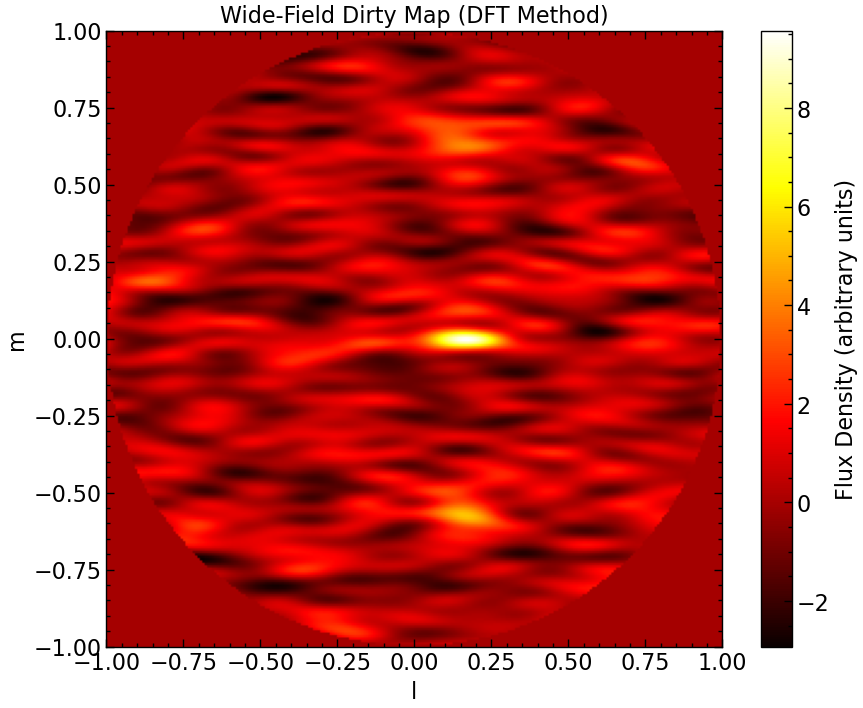

In [9]:
plt.figure(figsize=(10, 8))
plt.imshow(dirty_map, extent=[-1, 1, -1, 1], origin='lower', cmap='hot')
plt.colorbar(label='Flux Density (arbitrary units)')
plt.title('Wide-Field Dirty Map (DFT Method)')
plt.xlabel('l')
plt.ylabel('m')
plt.show()

In [10]:
from astropy.stats import sigma_clip
import scipy.ndimage as ndimage
def get_snr_map(dirty_map):
    """
    Generate an SNR map directly from the dirty image.
    Because the dirty map is a direct DFT of visibilities with independent thermal
    noise, it is *already* the optimal point source matched-filter output.
    """
    # Use sigma clipping to find the robust background RMS noise level
    # (ignoring bright sources that would otherwise inflate the standard deviation)
    clipped_map = sigma_clip(dirty_map, sigma=3.0, maxiters=5)
    sigma_image = np.std(clipped_map)
    
    # Calculate physical SNR map
    snr_map = np.abs(dirty_map / sigma_image)
    
    return snr_map

def detect_sources_from_snr(snr_map, threshold_sigma=5.0, min_distance=3):
    """
    Detect local peaks above threshold in the SNR map.
    """
    # 1. Find local maxima to avoid detecting every pixel surrounding a bright source
    local_max = ndimage.maximum_filter(snr_map, size=min_distance) == snr_map
    
    # 2. Apply sigma threshold detection
    above_threshold = snr_map > threshold_sigma
    
    # 3. Target pixels that satisfy both conditions
    detections = np.where(local_max & above_threshold)
    sources = []
    for y, x in zip(*detections):
        sources.append({
            "x_pixel": int(x),
            "y_pixel": int(y),
            "snr": float(snr_map[y, x])
        })
    # Sort sources by descending SNR so the brightest is first
    sources = sorted(sources, key=lambda s: s["snr"], reverse=True)
    return sources

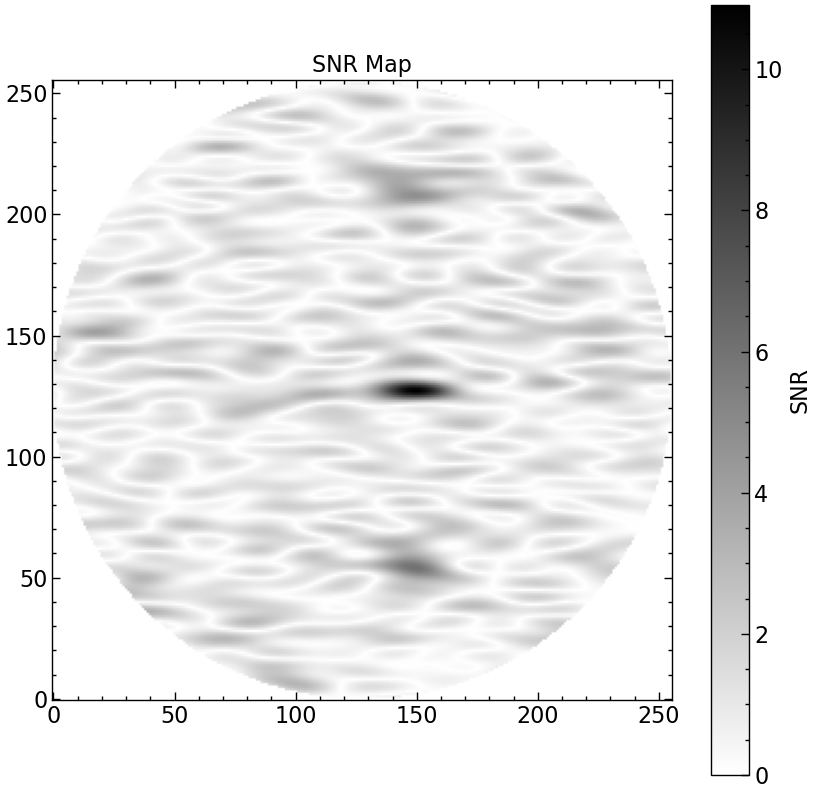

In [11]:
snr_map = get_snr_map(dirty_map)
plt.figure(figsize=(10, 10))
plt.imshow(snr_map, origin='lower', cmap='gray_r')
plt.colorbar(label='SNR')
plt.title('SNR Map')
plt.show()

In [12]:
detect_sources_from_snr(snr_map, threshold_sigma=5.0, min_distance=5)

[{'x_pixel': 149, 'y_pixel': 127, 'snr': 10.911768216986681},
 {'x_pixel': 149, 'y_pixel': 54, 'snr': 6.066480156496541}]

In [13]:
time_obs

<Time object: scale='utc' format='datetime' value=2026-02-28 00:42:39.904581>

In [14]:
sky_vis = generate_visibilities(antenna_mapping, 
                                frequencies, 
                                time_obs, 
                                Trec_k=25, 
                                a_eff_m2=0.2, 
                                integration_time_s = 1.0)

Generating sky model for 100 frequencies...
   Loading cached GSM model from gsm_cache/gsm_nch100_fmin375.00_fmax500.00_nside64.npy...
   Added Quiet Sun model (T_peak=8.00e+05 K, Diameter=1.2°)
Applying Gaussian primary beam...
Integrating over 24571 pixels (visible & within beam)
Beam-weighted sky temperature: [95.9483508  95.70007285 95.4547544  95.2123501  94.97281555 94.73610711
 94.50218187 94.27099784 94.0425137  93.81668893 93.59348374 93.37285906
 93.15477654 92.93919845 92.72608787 92.51540837 92.30712436 92.10120072
 91.89760306 91.69629756 91.49725093 91.30043061 91.1058045  90.9133411
 90.72300945 90.53477912 90.34862023 90.16461199 89.98289848 89.8034426
 89.6262053  89.45114842 89.27823456 89.10742708 88.93869015 88.77198858
 88.60728797 88.44455466 88.28375559 88.12485846 87.96783154 87.8126438
 87.65926483 87.5076648  87.35781451 87.20968536 87.06324927 86.91847874
 86.77534685 86.63382717 86.4938938  86.35552134 86.21868494 86.08336018
 85.94952312 85.81715033 85.6862

Processed frequency channel 0/100
Processed frequency channel 10/100
Processed frequency channel 20/100
Processed frequency channel 30/100
Processed frequency channel 40/100
Processed frequency channel 50/100
Processed frequency channel 60/100
Processed frequency channel 70/100
Processed frequency channel 80/100
Processed frequency channel 90/100
Adding thermal noise with Trec=25.0 K


In [15]:
sky_vis_template = generate_visibilities(antenna_mapping, 
                                frequencies, 
                                time_obs, 
                                Trec_k=25, 
                                a_eff_m2=0.2, 
                                integration_time_s = 60.0)

Generating sky model for 100 frequencies...
   Loading cached GSM model from gsm_cache/gsm_nch100_fmin375.00_fmax500.00_nside64.npy...
   Added Quiet Sun model (T_peak=8.00e+05 K, Diameter=1.2°)
Applying Gaussian primary beam...
Integrating over 24571 pixels (visible & within beam)
Beam-weighted sky temperature: [95.9483508  95.70007285 95.4547544  95.2123501  94.97281555 94.73610711
 94.50218187 94.27099784 94.0425137  93.81668893 93.59348374 93.37285906
 93.15477654 92.93919845 92.72608787 92.51540837 92.30712436 92.10120072
 91.89760306 91.69629756 91.49725093 91.30043061 91.1058045  90.9133411
 90.72300945 90.53477912 90.34862023 90.16461199 89.98289848 89.8034426
 89.6262053  89.45114842 89.27823456 89.10742708 88.93869015 88.77198858
 88.60728797 88.44455466 88.28375559 88.12485846 87.96783154 87.8126438
 87.65926483 87.5076648  87.35781451 87.20968536 87.06324927 86.91847874
 86.77534685 86.63382717 86.4938938  86.35552134 86.21868494 86.08336018
 85.94952312 85.81715033 85.6862

In [17]:
sky_vis = sky_vis["visibilities"][...,0,0]
sky_vis_template = sky_vis_template["visibilities"][...,0,0]

In [18]:
def altaz_to_lm(alt_deg, az_deg):
    """
    Convert Altitude and Azimuth (in degrees) to l, m direction cosines.
    """
    # Step 1: Convert to radians!
    alt_rad = np.radians(alt_deg)
    az_rad = np.radians(az_deg)
    
    # Step 2: Calculate ENU direction cosines
    l = np.cos(alt_rad) * np.sin(az_rad)
    m = np.cos(alt_rad) * np.cos(az_rad)
    
    return l, m


In [32]:
alt, az = 60, 90
vis_point = generate_point_source_visibilities(
    alt,
    az,
    10,
    frequencies,
    antenna_mapping,
    time_obs=time_obs,
    duration_s=1.0,
    Trec_k=25,
    a_eff_m2=0.2,
)
vis_point = vis_point[..., 0,0]

   Generating visibilities for point source at Alt=60.0, Az=90.0
   Apparent flux (with beam): 6.8592 Jy
   Adding thermal noise (Duration=1.0s, Trec=25K, Tsky=0.00K)...


In [33]:
l_axis = np.linspace(-1, 1, 256)

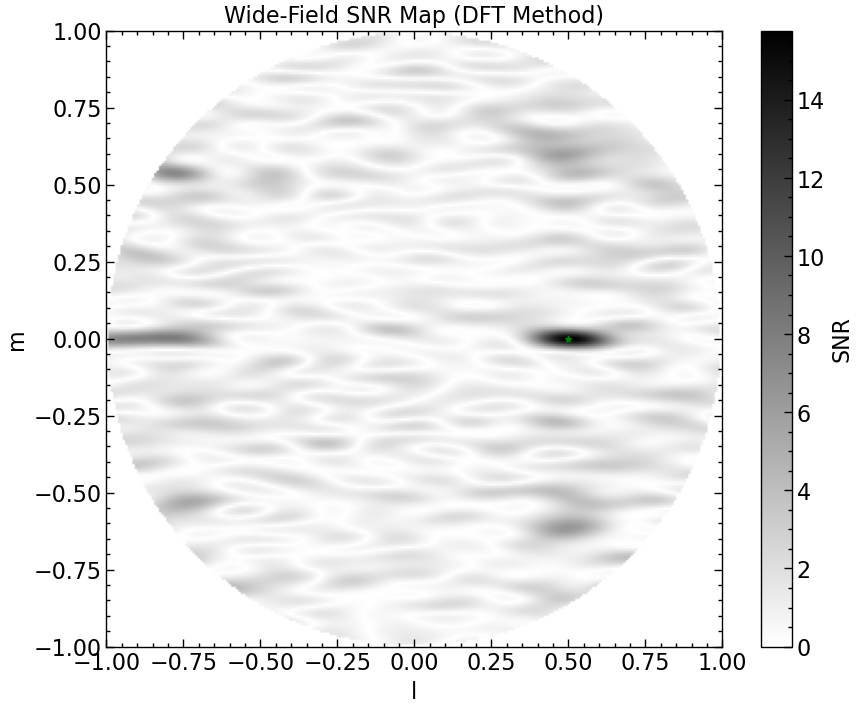

In [34]:
dirty_map_point = generate_dirty_map_gpu_chunked(vis_point, uvw_coords, res=256)
snr_map_point = get_snr_map(dirty_map_point)
plt.figure(figsize=(10, 8))
plt.imshow(snr_map_point, extent=[-1, 1, -1, 1], origin='lower', cmap='gray_r')
plt.colorbar(label='SNR')
l_inj, m_inj = altaz_to_lm(alt, az)
plt.scatter(l_inj, m_inj, color='g', marker='*', s=20)

plt.title('Wide-Field SNR Map (DFT Method)')
plt.xlabel('l')
plt.ylabel('m')
plt.show()

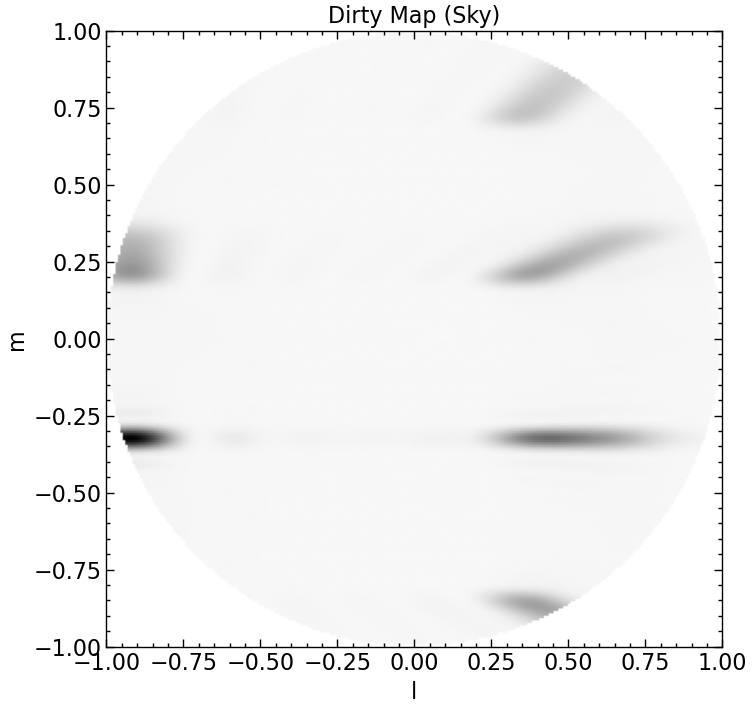

In [ ]:

dirty_map_sky = generate_dirty_map_gpu_chunked(sky_vis, uvw_coords, res=256)

plt.figure(figsize=(10, 8))
plt.imshow(dirty_map_sky, extent=[-1, 1, -1, 1], origin='lower', cmap='gray_r')
# plt.colorbar(label='SNR')

plt.title('Dirty Map (Sky)')
plt.xlabel('l')D
plt.ylabel('m')
plt.show()

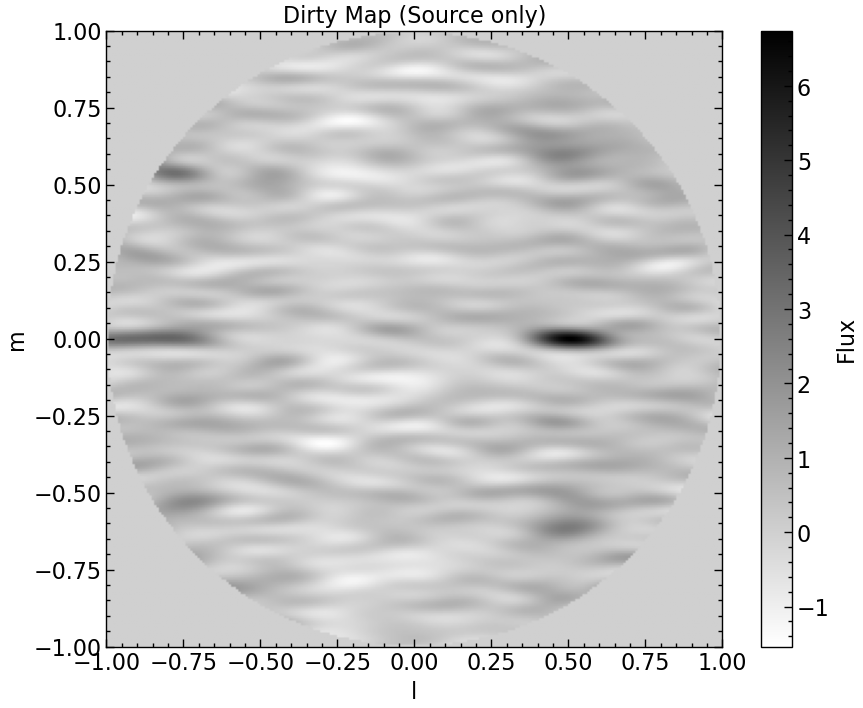

In [41]:
dirty_map_point = generate_dirty_map_gpu_chunked(vis_point, uvw_coords, res=256)
plt.figure(figsize=(10, 8))
plt.imshow(dirty_map_point, extent=[-1, 1, -1, 1], origin='lower', cmap='gray_r')
plt.colorbar(label='Flux')

plt.title('Dirty Map (Source only)')
plt.xlabel('l')
plt.ylabel('m')
plt.show()

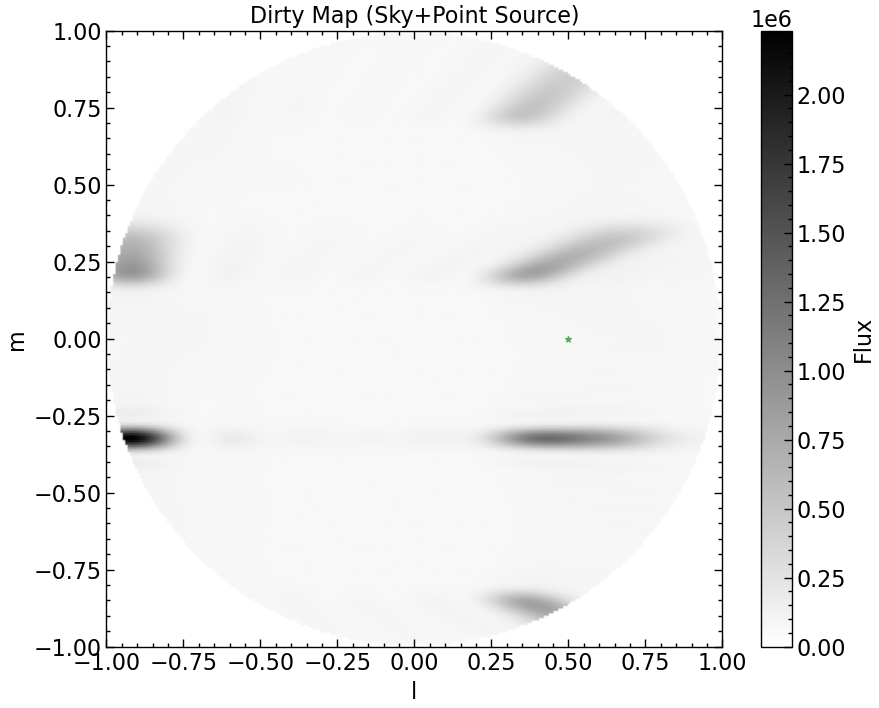

In [42]:

dirty_map_sky_src = generate_dirty_map_gpu_chunked(sky_vis+vis_point, uvw_coords, res=256)

plt.figure(figsize=(10, 8))
plt.imshow(dirty_map_sky_src, extent=[-1, 1, -1, 1], origin='lower', cmap='gray_r')
plt.colorbar(label='Flux')
l_inj, m_inj = altaz_to_lm(alt, az)
plt.scatter(l_inj, m_inj, color='g', marker='*', s=20, alpha = 0.5)
plt.title('Dirty Map (Sky+Point Source)')
plt.xlabel('l')
plt.ylabel('m')
plt.show()

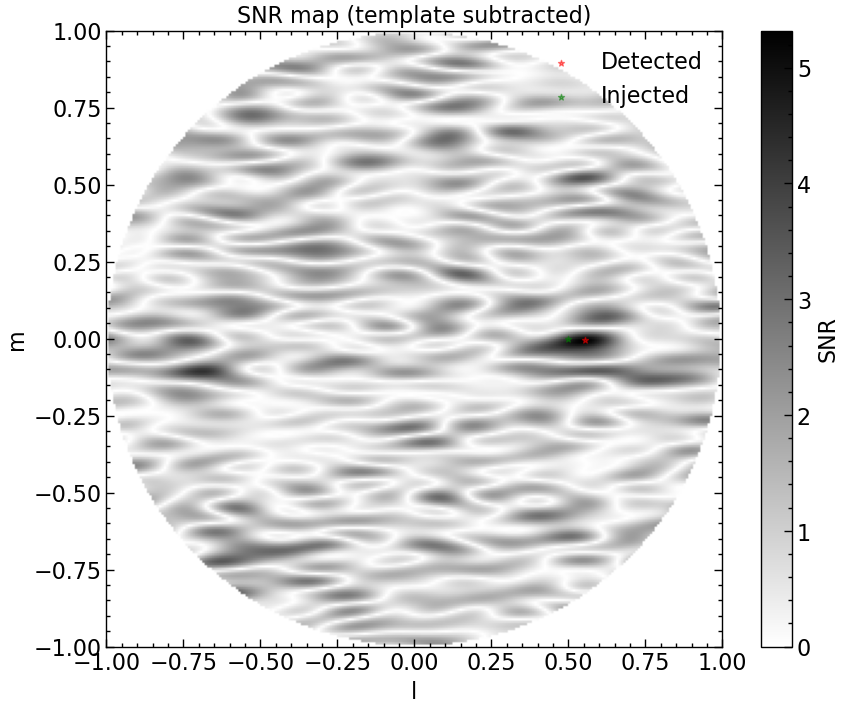

In [43]:

dirty_map_full = generate_dirty_map_gpu_chunked(sky_vis+vis_point-sky_vis_template, uvw_coords, res=256)
snr_map = get_snr_map(dirty_map_full)    
peak = detect_sources_from_snr(dirty_map_full)[0]
x_ind, y_ind = peak['x_pixel'], peak['y_pixel']

x_loc, y_loc = l_axis[x_ind], l_axis[y_ind]
plt.figure(figsize=(10, 8))
plt.imshow(snr_map, extent=[-1, 1, -1, 1], origin='lower', cmap='gray_r')
plt.colorbar(label='SNR')
plt.scatter(x_loc, y_loc, color='r', marker='*', s=20, alpha=0.5, label='Detected')
l_inj, m_inj = altaz_to_lm(alt, az)
plt.scatter(l_inj, m_inj, color='g', marker='*', s=20, alpha=0.5, label='Injected')

plt.title('SNR map (template subtracted)')
plt.xlabel('l')
plt.ylabel('m')
plt.legend()
plt.show()